In [3]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models

In [6]:
# 🔥 CHANGE PATH IF NEEDED

train_dir = "../data/raw/Training"
test_dir  = "../data/raw/Testing"

print(os.listdir(train_dir))

['glioma', 'meningioma', 'notumor', 'pituitary']


In [7]:
IMG_SIZE = 128

images = []
masks = []

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    
    for img_name in os.listdir(class_path)[:200]:  # limit for speed
        img_path = os.path.join(class_path, img_name)
        
        img = cv2.imread(img_path)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        
        # 🔥 PSEUDO MASK (threshold)
        _, mask = cv2.threshold(gray, 130, 255, cv2.THRESH_BINARY)
        
        images.append(img / 255.0)
        masks.append(mask / 255.0)

images = np.array(images)
masks = np.array(masks)

masks = np.expand_dims(masks, axis=-1)

print("Images shape:", images.shape)
print("Masks shape:", masks.shape)

Images shape: (800, 128, 128, 3)
Masks shape: (800, 128, 128, 1)


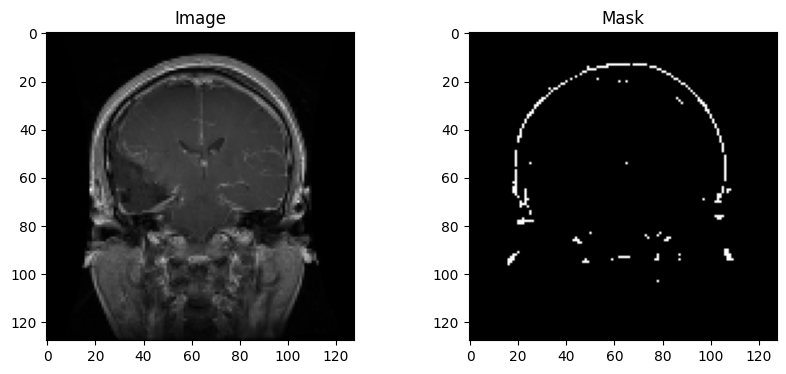

In [8]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(images[0])
plt.title("Image")

plt.subplot(1,2,2)
plt.imshow(masks[0].squeeze(), cmap='gray')
plt.title("Mask")

plt.show()

In [9]:
def build_unet(input_shape=(128,128,3)):
    
    inputs = layers.Input(input_shape)
    
    # Encoder
    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(inputs)
    p1 = layers.MaxPooling2D()(c1)
    
    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(p1)
    p2 = layers.MaxPooling2D()(c2)
    
    # Bottleneck
    b = layers.Conv2D(64, 3, activation='relu', padding='same')(p2)
    
    # Decoder
    u1 = layers.UpSampling2D()(b)
    c3 = layers.Conv2D(32, 3, activation='relu', padding='same')(u1)
    
    u2 = layers.UpSampling2D()(c3)
    c4 = layers.Conv2D(16, 3, activation='relu', padding='same')(u2)
    
    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c4)
    
    model_unet = models.Model(inputs, outputs)
    return model_unet

model_unet = build_unet()

model_unet.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_unet.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 16)   │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 128, 128, 1)    │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,689 (182.38 KB)

 Trainable params: 46,689 (182.38 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = model_unet.fit(
    images,
    masks,
    epochs=5,
    batch_size=16,
    validation_split=0.1
)

Epoch 1/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 141ms/step - accuracy: 0.9218 - loss: 0.3598 - val_accuracy: 0.9551 - val_loss: 0.1126
Epoch 2/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 114ms/step - accuracy: 0.9319 - loss: 0.1262 - val_accuracy: 0.9629 - val_loss: 0.0809
Epoch 3/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 115ms/step - accuracy: 0.9591 - loss: 0.0956 - val_accuracy: 0.9685 - val_loss: 0.0722
Epoch 4/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - accuracy: 0.9640 - loss: 0.0835 - val_accuracy: 0.9719 - val_loss: 0.0662
Epoch 5/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 98ms/step - accuracy: 0.9669 - loss: 0.0767 - val_accuracy: 0.9728 - val_loss: 0.0649


In [11]:
pred_mask = model_unet.predict(images[:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step


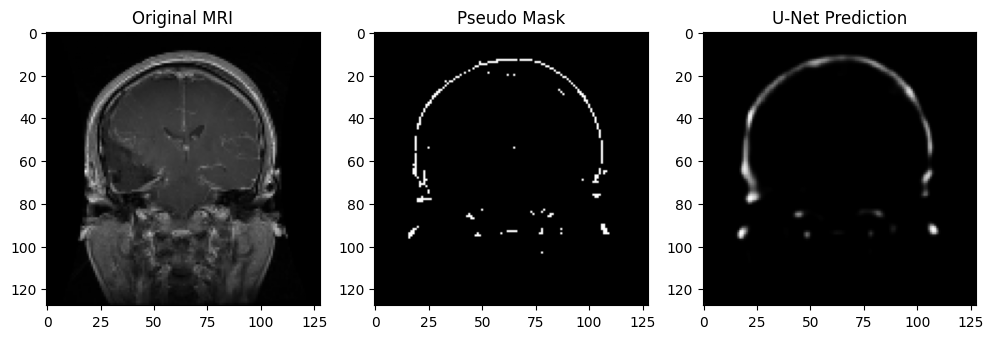

In [12]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(images[0])
plt.title("Original MRI")

plt.subplot(1,3,2)
plt.imshow(masks[0].squeeze(), cmap='gray')
plt.title("Pseudo Mask")

plt.subplot(1,3,3)
plt.imshow(pred_mask[0].squeeze(), cmap='gray')
plt.title("U-Net Prediction")

plt.show()